In [3]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import nbformat
import ast
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [4]:
# file names
data_file = "Transformed_TGSIM_Foggy_Bottom_200sec.xlsx"
polygon_file = "Polygons.ipynb"

# output files
dataset_summary_file = "dataset_description_summary.csv"
group_summary_file = "agent_group_summary.csv"
decel_agent_file = "deceleration_by_agent.csv"
decel_group_file = "deceleration_by_group.csv"
lane_summary_file = "lane_speed_summary.csv"

In [5]:
# load the main dataset
df = pd.read_excel(data_file)

# clean column names
df.columns = df.columns.str.strip()

# sort by id and time
df = df.sort_values(["id", "time"]).reset_index(drop=True)

# quick check
print(df.head())
print(df.columns.tolist())

    id    time     xloc_kf     yloc_kf  lane_kf  speed_kf_x  speed_kf_y  acceleration_kf_x  acceleration_kf_y  length_smoothed  width_smoothed  type_most_common
0  165  3700.0  183.966348  308.305096       36    0.108236    6.005233           0.018661           0.802440             15.0        2.413078                 7
1  165  3700.1  183.978291  308.896475       36    0.119433    5.913793           0.111968          -0.914408             15.0        2.413078                 7
2  165  3700.2  183.991354  309.478151       36    0.130630    5.816753           0.111968          -0.970392             15.0        2.413078                 7
3  165  3700.3  184.004604  310.048069       36    0.132496    5.699187           0.018661          -1.175667             15.0        2.413078                 7
4  165  3700.4  184.017107  310.605112       36    0.125031    5.570423          -0.074646          -1.287635             15.0        2.413078                 7
['id', 'time', 'xloc_kf', 'yloc_kf

In [6]:
# readable labels for agent types
type_map = {
    0: "Pedestrian",
    1: "Bicycle",
    2: "Scooter",
    3: "Passenger Car",
    4: "Automated Vehicle",
    5: "Motorcycle",
    6: "Bus",
    7: "Truck"
}

df["agent_type"] = df["type_most_common"].map(type_map)

# main groups for the report
def group_agent(agent_type):
    if agent_type == "Automated Vehicle":
        return "AV"
    elif agent_type == "Passenger Car":
        return "Non-AV Passenger Vehicle"
    elif agent_type == "Pedestrian":
        return "Pedestrian"
    else:
        return "Other"

df["report_group"] = df["agent_type"].apply(group_agent)

# keep a quick count
print(df["report_group"].value_counts(dropna=False))

report_group
Non-AV Passenger Vehicle    47143
Pedestrian                  18290
Other                        3953
AV                           1975
Name: count, dtype: int64


In [7]:
# speed, acceleration, and change values
df["speed_total"] = np.sqrt(df["speed_kf_x"]**2 + df["speed_kf_y"]**2)
df["accel_total"] = np.sqrt(df["acceleration_kf_x"]**2 + df["acceleration_kf_y"]**2)

df["dt"] = df.groupby("id")["time"].diff()
df["speed_change"] = df.groupby("id")["speed_total"].diff()
df["signed_accel"] = df["speed_change"] / df["dt"]

df["signed_accel"] = df["signed_accel"].replace([np.inf, -np.inf], np.nan)

# optional extra measure
df["jerk"] = df.groupby("id")["signed_accel"].diff() / df["dt"]
df["jerk"] = df["jerk"].replace([np.inf, -np.inf], np.nan)

print(df[["id", "time", "speed_total", "signed_accel", "jerk"]].head(10))

    id    time  speed_total  signed_accel      jerk
0  165  3700.0     6.006209           NaN       NaN
1  165  3700.1     5.914998     -0.912102       NaN
2  165  3700.2     5.818220     -0.967785 -0.556825
3  165  3700.3     5.700727     -1.174934 -2.071494
4  165  3700.4     5.571826     -1.289005 -1.140706
5  165  3700.5     5.433561     -1.382653 -0.936481
6  165  3700.6     5.289596     -1.439647 -0.569939
7  165  3700.7     5.143763     -1.458332 -0.186858
8  165  3700.8     4.994213     -1.495495 -0.371625
9  165  3700.9     4.844702     -1.495112  0.003833


In [8]:
# dataset description table
dataset_summary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": [str(df[col].dtype) for col in df.columns],
    "non_null_count": [df[col].notna().sum() for col in df.columns],
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
})

print(dataset_summary)
dataset_summary.to_csv(dataset_summary_file, index=False)

          column_name data_type  non_null_count  unique_values
0                  id     int64           71361            564
1                time   float64           71361           2001
2             xloc_kf   float64           71361          48856
3             yloc_kf   float64           71361          51375
4             lane_kf     int64           71361             46
5          speed_kf_x   float64           71361          17598
6          speed_kf_y   float64           71361          25575
7   acceleration_kf_x   float64           71361          22710
8   acceleration_kf_y   float64           71361          26575
9     length_smoothed   float64           71361             31
10     width_smoothed   float64           71361             73
11   type_most_common     int64           71361              8
12         agent_type    object           71361              8
13       report_group    object           71361              4
14        speed_total   float64           71361        

In [9]:
# keep only the three main groups for the main report
main_df = df[df["report_group"].isin(["AV", "Non-AV Passenger Vehicle", "Pedestrian"])].copy()

print(main_df["report_group"].value_counts())

report_group
Non-AV Passenger Vehicle    47143
Pedestrian                  18290
AV                           1975
Name: count, dtype: int64


In [10]:
# summary stats by group
group_summary = main_df.groupby("report_group").agg(
    observations=("id", "size"),
    unique_agents=("id", "nunique"),
    mean_speed=("speed_total", "mean"),
    median_speed=("speed_total", "median"),
    std_speed=("speed_total", "std"),
    mean_signed_accel=("signed_accel", "mean"),
    median_signed_accel=("signed_accel", "median"),
    std_signed_accel=("signed_accel", "std"),
    mean_accel_magnitude=("accel_total", "mean"),
    median_accel_magnitude=("accel_total", "median"),
    mean_jerk=("jerk", "mean"),
    median_jerk=("jerk", "median")
).reset_index()

print(group_summary)
group_summary.to_csv(group_summary_file, index=False)

               report_group  observations  unique_agents  mean_speed  median_speed  std_speed  mean_signed_accel  median_signed_accel  std_signed_accel  mean_accel_magnitude  median_accel_magnitude  \
0                        AV          1975              1    2.470593      2.683821   2.144249           0.009448         0.000000e+00          0.491654              0.383804                0.187545   
1  Non-AV Passenger Vehicle         47143            157    3.256133      0.184455   4.832910           0.025707         3.295931e-13          1.099845              0.580965                0.083456   
2                Pedestrian         18290            380    1.302075      1.492228   0.768391           0.012156         8.196510e-04          0.334949              0.302187                0.253822   

   mean_jerk   median_jerk  
0  -0.012751 -8.273503e-12  
1  -0.141695  0.000000e+00  
2  -0.098599 -1.920362e-02  


In [11]:
# summary stats by group
group_summary = main_df.groupby("report_group").agg(
    observations=("id", "size"),
    unique_agents=("id", "nunique"),
    mean_speed=("speed_total", "mean"),
    median_speed=("speed_total", "median"),
    std_speed=("speed_total", "std"),
    mean_signed_accel=("signed_accel", "mean"),
    median_signed_accel=("signed_accel", "median"),
    std_signed_accel=("signed_accel", "std"),
    mean_accel_magnitude=("accel_total", "mean"),
    median_accel_magnitude=("accel_total", "median"),
    mean_jerk=("jerk", "mean"),
    median_jerk=("jerk", "median")
).reset_index()

print(group_summary)
group_summary.to_csv(group_summary_file, index=False)

               report_group  observations  unique_agents  mean_speed  median_speed  std_speed  mean_signed_accel  median_signed_accel  std_signed_accel  mean_accel_magnitude  median_accel_magnitude  \
0                        AV          1975              1    2.470593      2.683821   2.144249           0.009448         0.000000e+00          0.491654              0.383804                0.187545   
1  Non-AV Passenger Vehicle         47143            157    3.256133      0.184455   4.832910           0.025707         3.295931e-13          1.099845              0.580965                0.083456   
2                Pedestrian         18290            380    1.302075      1.492228   0.768391           0.012156         8.196510e-04          0.334949              0.302187                0.253822   

   mean_jerk   median_jerk  
0  -0.012751 -8.273503e-12  
1  -0.141695  0.000000e+00  
2  -0.098599 -1.920362e-02  


In [12]:
# speed consistency by lane / polygon id
lane_summary = main_df.groupby(["lane_kf", "report_group"]).agg(
    observations=("id", "size"),
    unique_agents=("id", "nunique"),
    mean_speed=("speed_total", "mean"),
    median_speed=("speed_total", "median"),
    std_speed=("speed_total", "std"),
    mean_signed_accel=("signed_accel", "mean")
).reset_index()

print(lane_summary.head(20))
lane_summary.to_csv(lane_summary_file, index=False)

    lane_kf              report_group  observations  unique_agents  mean_speed  median_speed  std_speed  mean_signed_accel
0         1                        AV            25              1    6.880175      6.933618   0.274558          -0.066325
1         1  Non-AV Passenger Vehicle          1054             68    9.790424     10.362514   3.941144           0.449803
2         1                Pedestrian          1256             28    1.072951      1.151666   0.832248          -0.028365
3         2                        AV           125              1    1.180643      0.829582   1.151501          -0.122394
4         2  Non-AV Passenger Vehicle           345             13    5.043271      4.893075   1.740306           0.031802
5         2                Pedestrian           177             14    1.034401      1.209885   0.471199          -0.034826
6         3                        AV            34              1    3.745208      3.762964   0.088039           0.059248
7         3  Non

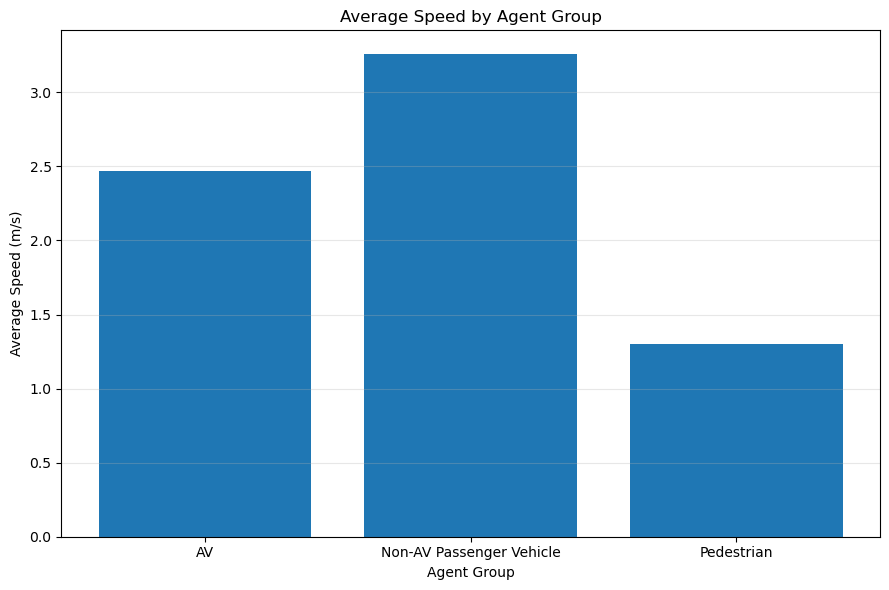

In [13]:
# average speed plot
plt.figure(figsize=(9, 6))
plt.bar(group_summary["report_group"], group_summary["mean_speed"])
plt.title("Average Speed by Agent Group")
plt.xlabel("Agent Group")
plt.ylabel("Average Speed (m/s)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

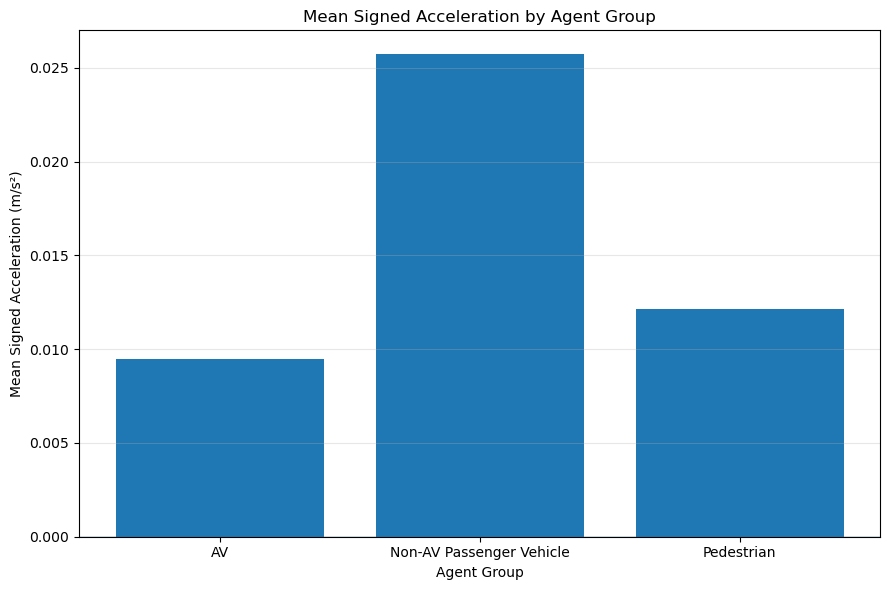

In [14]:
# mean signed acceleration plot
plt.figure(figsize=(9, 6))
plt.bar(group_summary["report_group"], group_summary["mean_signed_accel"])
plt.title("Mean Signed Acceleration by Agent Group")
plt.xlabel("Agent Group")
plt.ylabel("Mean Signed Acceleration (m/s²)")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# lane speed profile plot
plt.figure(figsize=(12, 7))

for group_name in lane_summary["report_group"].dropna().unique():
    temp = lane_summary[lane_summary["report_group"] == group_name].sort_values("lane_kf")
    plt.plot(temp["lane_kf"], temp["mean_speed"], marker="o", label=group_name)

plt.title("Speed Profile by Lane / Polygon ID")
plt.xlabel("Lane / Polygon ID")
plt.ylabel("Mean Speed (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# threshold for strong deceleration
decel_threshold = -2.0

# flag rows with strong deceleration
main_df["hard_decel_flag"] = main_df["signed_accel"] <= decel_threshold

# count per agent
decel_by_agent = main_df.groupby(["id", "report_group"]).agg(
    hard_decel_events=("hard_decel_flag", "sum"),
    mean_speed=("speed_total", "mean"),
    mean_signed_accel=("signed_accel", "mean")
).reset_index()

# count per group
decel_by_group = decel_by_agent.groupby("report_group").agg(
    agents_in_group=("id", "nunique"),
    total_hard_decel_events=("hard_decel_events", "sum"),
    mean_hard_decel_events_per_agent=("hard_decel_events", "mean"),
    median_hard_decel_events_per_agent=("hard_decel_events", "median")
).reset_index()

print(decel_by_group)

               report_group  agents_in_group  total_hard_decel_events  mean_hard_decel_events_per_agent  median_hard_decel_events_per_agent
0                        AV                1                        1                          1.000000                                 1.0
1  Non-AV Passenger Vehicle              157                     2077                         13.229299                                16.0
2                Pedestrian              380                        0                          0.000000                                 0.0


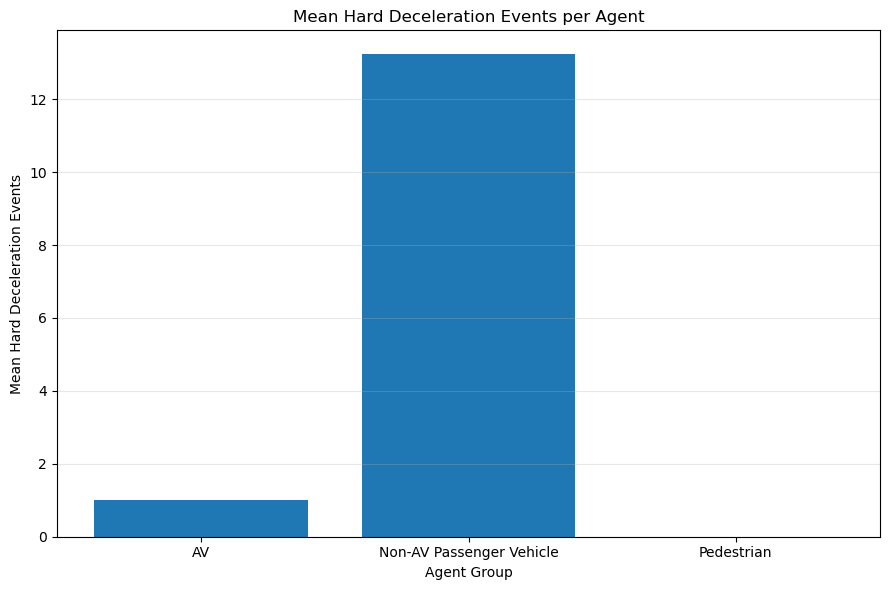

In [17]:
# hard deceleration events plot
plt.figure(figsize=(9, 6))
plt.bar(decel_by_group["report_group"], decel_by_group["mean_hard_decel_events_per_agent"])
plt.title("Mean Hard Deceleration Events per Agent")
plt.xlabel("Agent Group")
plt.ylabel("Mean Hard Deceleration Events")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

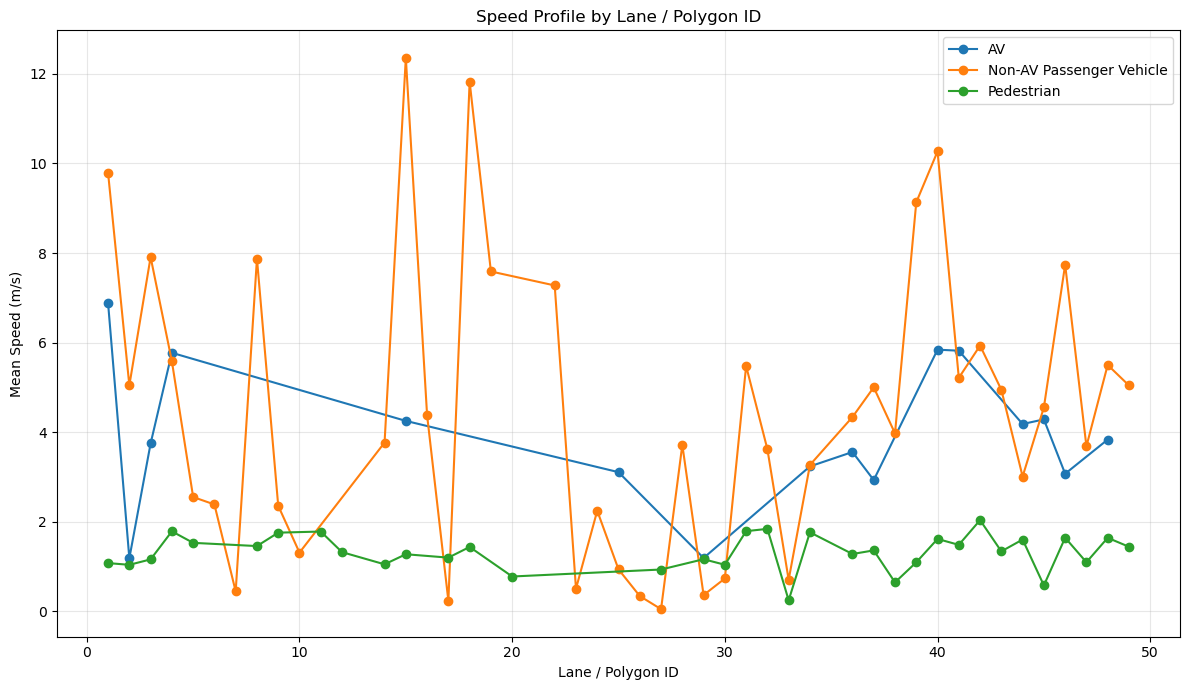

In [18]:
# lane speed profile plot
plt.figure(figsize=(12, 7))

for group_name in lane_summary["report_group"].dropna().unique():
    temp = lane_summary[lane_summary["report_group"] == group_name].sort_values("lane_kf")
    plt.plot(temp["lane_kf"], temp["mean_speed"], marker="o", label=group_name)

plt.title("Speed Profile by Lane / Polygon ID")
plt.xlabel("Lane / Polygon ID")
plt.ylabel("Mean Speed (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# load polygon data from the notebook
with open(polygon_file, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

all_code = "\n".join(cell.source for cell in nb.cells if cell.cell_type == "code")

match = re.search(r"polygons\s*=\s*(\{.*\})", all_code, re.S)

if match is None:
    raise ValueError("Could not find polygons dictionary in Polygons.ipynb")

polygons = ast.literal_eval(match.group(1))

print(type(polygons))
print(list(polygons.keys())[:10])

<class 'dict'>
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


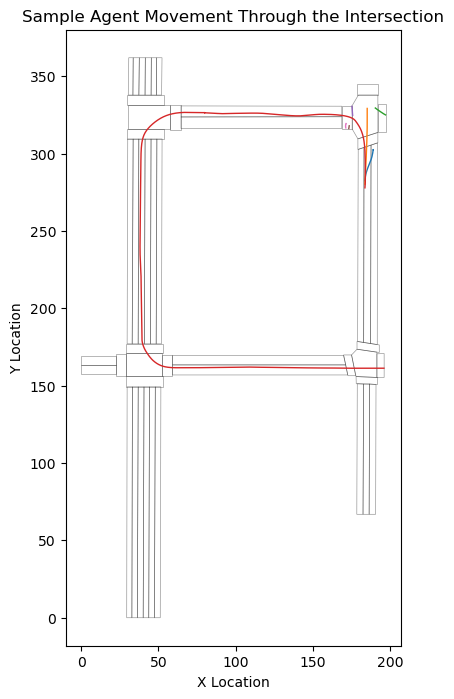

In [22]:
# sample movement plot on top of polygon outlines
fig, ax = plt.subplots(figsize=(8, 8))

# draw polygon outlines
for poly_id, coords in polygons.items():
    coords_array = np.array(coords)
    patch = MplPolygon(coords_array, closed=True, fill=False, linewidth=0.5, alpha=0.4)
    ax.add_patch(patch)

# choose a few sample ids from each main group
sample_ids = []

for group_name in ["AV", "Non-AV Passenger Vehicle", "Pedestrian"]:
    ids_here = main_df.loc[main_df["report_group"] == group_name, "id"].drop_duplicates().head(3).tolist()
    sample_ids.extend(ids_here)

plot_df = main_df[main_df["id"].isin(sample_ids)].copy()

for agent_id in plot_df["id"].unique():
    temp = plot_df[plot_df["id"] == agent_id].sort_values("time")
    ax.plot(temp["xloc_kf"], temp["yloc_kf"], linewidth=1)

ax.set_title("Sample Agent Movement Through the Intersection")
ax.set_xlabel("X Location")
ax.set_ylabel("Y Location")
ax.set_aspect("equal")

plt.show()
plt.close()

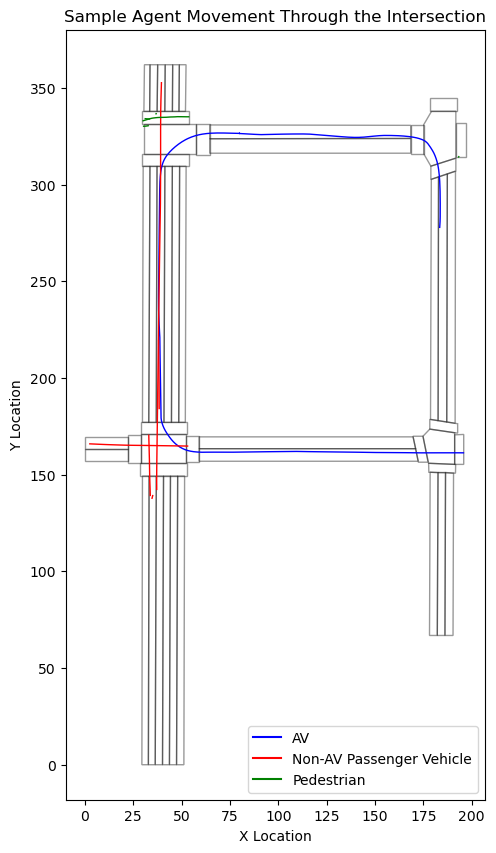

In [24]:
# sample movement plot with random agents and group colors
fig, ax = plt.subplots(figsize=(10, 10))

color_map = {
    "AV": "blue",
    "Non-AV Passenger Vehicle": "red",
    "Pedestrian": "green"
}

# draw polygons first
for poly_id, coords in polygons.items():
    patch = MplPolygon(coords, closed=True, fill=False, alpha=0.4)
    ax.add_patch(patch)

# pick random sample ids from each group
sample_ids = []

for group_name in ["AV", "Non-AV Passenger Vehicle", "Pedestrian"]:
    group_ids = main_df.loc[main_df["report_group"] == group_name, "id"].drop_duplicates()
    ids_here = group_ids.sample(n=min(5, len(group_ids)), random_state=None).tolist()
    sample_ids.extend(ids_here)

plot_df = main_df[main_df["id"].isin(sample_ids)].copy()

# plot each sampled agent
for agent_id in plot_df["id"].unique():
    temp = plot_df[plot_df["id"] == agent_id].sort_values("time")
    group_name = temp["report_group"].iloc[0]
    ax.plot(temp["xloc_kf"], temp["yloc_kf"], color=color_map[group_name], linewidth=1)

# legend
for group_name, color in color_map.items():
    ax.plot([], [], color=color, label=group_name)

ax.legend()
ax.set_title("Sample Agent Movement Through the Intersection")
ax.set_xlabel("X Location")
ax.set_ylabel("Y Location")
ax.set_aspect("equal")
plt.show()

In [25]:
# average speed inside each lane for the three groups
lane_pivot = lane_summary.pivot(index="lane_kf", columns="report_group", values="mean_speed")

print(lane_pivot.head(20))

report_group        AV  Non-AV Passenger Vehicle  Pedestrian
lane_kf                                                     
1             6.880175                  9.790424    1.072951
2             1.180643                  5.043271    1.034401
3             3.745208                  7.909291    1.156026
4             5.770939                  5.582109    1.782479
5                  NaN                  2.548464    1.525341
6                  NaN                  2.382715         NaN
7                  NaN                  0.440329         NaN
8                  NaN                  7.875868    1.453520
9                  NaN                  2.353673    1.752929
10                 NaN                  1.307719         NaN
11                 NaN                       NaN    1.777856
12                 NaN                       NaN    1.317669
14                 NaN                  3.765045    1.045567
15            4.249647                 12.358909    1.270713
16                 NaN  

In [26]:
# top lanes with the largest speed differences
lane_compare = lane_pivot.copy()

# only keep rows where at least two groups are present
lane_compare["max_speed"] = lane_compare.max(axis=1)
lane_compare["min_speed"] = lane_compare.min(axis=1)
lane_compare["speed_range"] = lane_compare["max_speed"] - lane_compare["min_speed"]

lane_compare = lane_compare.sort_values("speed_range", ascending=False)

print(lane_compare.head(15))

report_group        AV  Non-AV Passenger Vehicle  Pedestrian  max_speed  min_speed  speed_range
lane_kf                                                                                        
15            4.249647                 12.358909    1.270713  12.358909   1.270713    11.088196
18                 NaN                 11.828353    1.433504  11.828353   1.433504    10.394849
1             6.880175                  9.790424    1.072951   9.790424   1.072951     8.717473
40            5.840937                 10.269935    1.612276  10.269935   1.612276     8.657658
39                 NaN                  9.133452    1.090727   9.133452   1.090727     8.042725
3             3.745208                  7.909291    1.156026   7.909291   1.156026     6.753265
8                  NaN                  7.875868    1.453520   7.875868   1.453520     6.422347
46            3.069199                  7.740007    1.639672   7.740007   1.639672     6.100335
41            5.817901                  

In [27]:
# simple written summary values to copy into the report
fastest_group = group_summary.loc[group_summary["mean_speed"].idxmax(), "report_group"]
slowest_group = group_summary.loc[group_summary["mean_speed"].idxmin(), "report_group"]

most_decel_group = decel_by_group.loc[decel_by_group["mean_hard_decel_events_per_agent"].idxmax(), "report_group"]
least_decel_group = decel_by_group.loc[decel_by_group["mean_hard_decel_events_per_agent"].idxmin(), "report_group"]

print("Fastest average group:", fastest_group)
print("Slowest average group:", slowest_group)
print("Most hard deceleration events per agent:", most_decel_group)
print("Fewest hard deceleration events per agent:", least_decel_group)

Fastest average group: Non-AV Passenger Vehicle
Slowest average group: Pedestrian
Most hard deceleration events per agent: Non-AV Passenger Vehicle
Fewest hard deceleration events per agent: Pedestrian


<Figure size 1000x600 with 0 Axes>

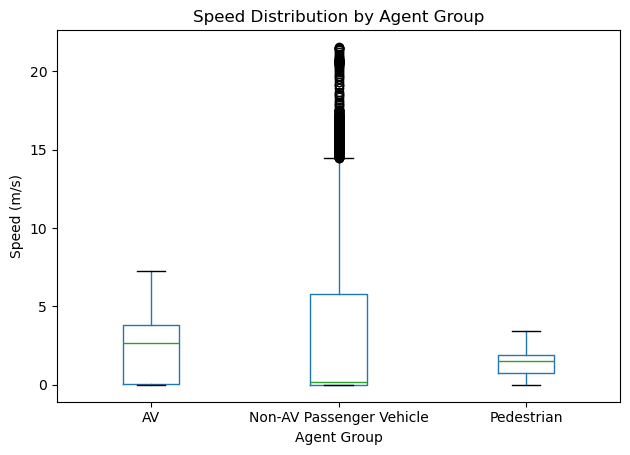

In [28]:
# boxplot for speed spread
plt.figure(figsize=(10, 6))

main_df.boxplot(column="speed_total", by="report_group", grid=False)

plt.title("Speed Distribution by Agent Group")
plt.suptitle("")
plt.xlabel("Agent Group")
plt.ylabel("Speed (m/s)")
plt.tight_layout()
plt.show()